# Mental Health Classification — Classical Models
**Project:** Social Media and Mental Health — A Machine Learning Analysis of Reddit Discourse  
**Authors:** Ardhra Ann Denny, Manu Sharanya Bhadriraju  
**Labels:** Anxiety, Depression, SuicideWatch  
**Primary metric:** Macro F1  
**Models:** Logistic Regression, Naive Bayes, SVM, XGBoost, MLP  
**Evaluation:** 5-fold stratified CV + held-out test set  

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, MaxAbsScaler
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    confusion_matrix, classification_report
)
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)



In [13]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')

print(f'Train: {len(train_df)} rows')
print(train_df['label'].value_counts())
print(f'\nTest: {len(test_df)} rows')
print(test_df['label'].value_counts())

CLASSES = ['Anxiety', 'Depression', 'SuicideWatch']

y_train = train_df['label'].values
y_test  = test_df['label'].values

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
print(f'Label mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Train: 9410 rows
label
Anxiety         3181
Depression      3118
SuicideWatch    3111
Name: count, dtype: int64

Test: 2353 rows
label
Anxiety         796
Depression      779
SuicideWatch    778
Name: count, dtype: int64
Label mapping: {'Anxiety': np.int64(0), 'Depression': np.int64(1), 'SuicideWatch': np.int64(2)}


In [ ]:
def objective(trial):
    model_name   = trial.suggest_categorical('model', ['LR', 'SVM'])
    max_features = trial.suggest_int('max_features', 20000, 60000, step=10000)
    ngram_max    = trial.suggest_int('ngram_max', 1, 3)
    use_char     = trial.suggest_categorical('use_char', [True, False])
    C            = trial.suggest_float('C', 0.01, 10.0, log=True)

    word_vec = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, ngram_max),
        sublinear_tf=True,
        min_df=2, max_df=0.95
    )

    if use_char:
        char_vec = TfidfVectorizer(
            max_features=20000,
            ngram_range=(3, 5),
            sublinear_tf=True,
            analyzer='char_wb'
        )
        features = FeatureUnion([('word', word_vec), ('char', char_vec)])
    else:
        features = word_vec

    X_trial = features.fit_transform(train_df['clean_text'])

    if model_name == 'LR':
        model = LogisticRegression(C=C, class_weight='balanced',
                                   max_iter=1000, random_state=42)
    else:
        model = LinearSVC(C=C, class_weight='balanced',
                          max_iter=5000, random_state=42)

    scores = cross_val_score(model, X_trial, y_train, cv=5, scoring='f1_macro')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=40)

print(f'Best macro F1 : {study.best_value:.4f}')
print(f'Best params   : {study.best_params}')

BEST_C            = study.best_params['C']
BEST_MAX_FEATURES = study.best_params['max_features']
BEST_NGRAM_MAX    = study.best_params['ngram_max']
BEST_USE_CHAR     = study.best_params['use_char']
BEST_MODEL        = study.best_params['model']

Best macro F1 : 0.7384
Best params   : {'model': 'LR', 'max_features': 30000, 'ngram_max': 2, 'use_char': True, 'C': 0.14430280788405636}


In [27]:
word_tfidf = TfidfVectorizer(
    max_features=BEST_MAX_FEATURES,
    ngram_range=(1, BEST_NGRAM_MAX),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95,
    analyzer='word'
)

char_tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(3, 5),
    sublinear_tf=True,
    analyzer='char_wb'
)

if BEST_USE_CHAR:
    combined_features = FeatureUnion([('word', word_tfidf), ('char', char_tfidf)])
else:
    combined_features = word_tfidf

X_train = combined_features.fit_transform(train_df['clean_text'])
X_test  = combined_features.transform(test_df['clean_text'])

print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')


X_train shape : (9410, 50000)
X_test shape  : (2353, 50000)


In [16]:
models = {
    'Logistic Regression': LogisticRegression(
        C=BEST_C if BEST_MODEL == 'LR' else 1.0,
        max_iter=2000,
        class_weight='balanced',
        solver='saga',
        random_state=42
    ),
    'Naive Bayes': MultinomialNB(
        alpha=0.1
    ),
    'SVM': CalibratedClassifierCV(
        LinearSVC(
            C=BEST_C if BEST_MODEL == 'SVM' else 1.0,
            class_weight='balanced',
            max_iter=5000,
            random_state=42
        ),
        cv=3
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=0.5,
        min_child_weight=5,
        gamma=0.1,
        eval_metric='mlogloss',
        objective='multi:softmax',
        num_class=3,
        device='cpu',
        random_state=42
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),
        activation='relu',
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=300,
        batch_size=64,
        random_state=42
    )
}

print('Models defined:')
for name in models:
    print(f'  - {name}')

Models defined:
  - Logistic Regression
  - Naive Bayes
  - SVM
  - XGBoost
  - MLP


In [17]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {name: {'macro_f1': [], 'acc': []} for name in models}

for name, model in models.items():
    print(f'\n{"-"*45}')
    print(f'  {name}')
    print(f'{"-"*45}')

    use_enc = (name == 'XGBoost')
    y_cv = y_train_enc if use_enc else y_train

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, y_cv)):
        X_tr,  X_val  = X_train[tr_idx], X_train[val_idx]
        y_tr,  y_val  = y_cv[tr_idx],    y_cv[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        if use_enc:
            preds_dec = le.inverse_transform(preds)
            y_val_dec = le.inverse_transform(y_val)
        else:
            preds_dec = preds
            y_val_dec = y_val

        macro_f1 = f1_score(y_val_dec, preds_dec, average='macro')
        acc      = accuracy_score(y_val_dec, preds_dec)
        cv_results[name]['macro_f1'].append(macro_f1)
        cv_results[name]['acc'].append(acc)
        print(f'  Fold {fold+1} — Macro F1: {macro_f1:.4f}  Acc: {acc:.4f}')

    mean_f1  = np.mean(cv_results[name]['macro_f1'])
    std_f1   = np.std(cv_results[name]['macro_f1'])
    mean_acc = np.mean(cv_results[name]['acc'])
    print(f'  Mean Macro F1: {mean_f1:.4f} +/- {std_f1:.4f} | Mean Acc: {mean_acc:.4f}')


---------------------------------------------
  Logistic Regression
---------------------------------------------
  Fold 1 — Macro F1: 0.7342  Acc: 0.7343
  Fold 2 — Macro F1: 0.7248  Acc: 0.7253
  Fold 3 — Macro F1: 0.7414  Acc: 0.7412
  Fold 4 — Macro F1: 0.7352  Acc: 0.7327
  Fold 5 — Macro F1: 0.7442  Acc: 0.7439
  Mean Macro F1: 0.7359 +/- 0.0067 | Mean Acc: 0.7355

---------------------------------------------
  Naive Bayes
---------------------------------------------
  Fold 1 — Macro F1: 0.7135  Acc: 0.7152
  Fold 2 — Macro F1: 0.7077  Acc: 0.7094
  Fold 3 — Macro F1: 0.7161  Acc: 0.7168
  Fold 4 — Macro F1: 0.7187  Acc: 0.7179
  Fold 5 — Macro F1: 0.7089  Acc: 0.7104
  Mean Macro F1: 0.7130 +/- 0.0042 | Mean Acc: 0.7139

---------------------------------------------
  SVM
---------------------------------------------
  Fold 1 — Macro F1: 0.7107  Acc: 0.7120
  Fold 2 — Macro F1: 0.7131  Acc: 0.7141
  Fold 3 — Macro F1: 0.7239  Acc: 0.7248
  Fold 4 — Macro F1: 0.7240  Acc: 0.72

In [18]:
test_results = []

for name, model in models.items():
    use_enc = (name == 'XGBoost')

    model.fit(X_train, y_train_enc if use_enc else y_train)
    preds_raw = model.predict(X_test)
    preds = le.inverse_transform(preds_raw) if use_enc else preds_raw

    try:
        if hasattr(model, 'predict_proba'):
            proba = model.predict_proba(X_test)
            auc = round(roc_auc_score(
                y_test, proba,
                multi_class='ovr',
                average='macro'
            ), 4)
        else:
            auc = 'N/A'
    except Exception:
        auc = 'N/A'

    macro_f1 = f1_score(y_test, preds, average='macro')
    acc      = accuracy_score(y_test, preds)
    cv_mean  = np.mean(cv_results[name]['macro_f1'])
    cv_std   = np.std(cv_results[name]['macro_f1'])

    test_results.append({
        'Model':         name,
        'CV Macro F1':   round(cv_mean,  4),
        'CV Std':        round(cv_std,   4),
        'Test Macro F1': round(macro_f1, 4),
        'Test Acc':      round(acc,      4),
        'AUC-ROC':       auc
    })

results_df = pd.DataFrame(test_results).sort_values('Test Macro F1', ascending=False)

print('\n===== Our Results =====')
print(results_df.to_string(index=False))



===== Our Results =====
              Model  CV Macro F1  CV Std  Test Macro F1  Test Acc  AUC-ROC
Logistic Regression       0.7359  0.0067         0.7467    0.7463   0.8969
            XGBoost       0.7228  0.0086         0.7424    0.7408   0.8948
                SVM       0.7195  0.0063         0.7355    0.7361   0.8846
        Naive Bayes       0.7130  0.0042         0.7083    0.7097   0.8763
                MLP       0.7036  0.0109         0.7061    0.7080   0.8696


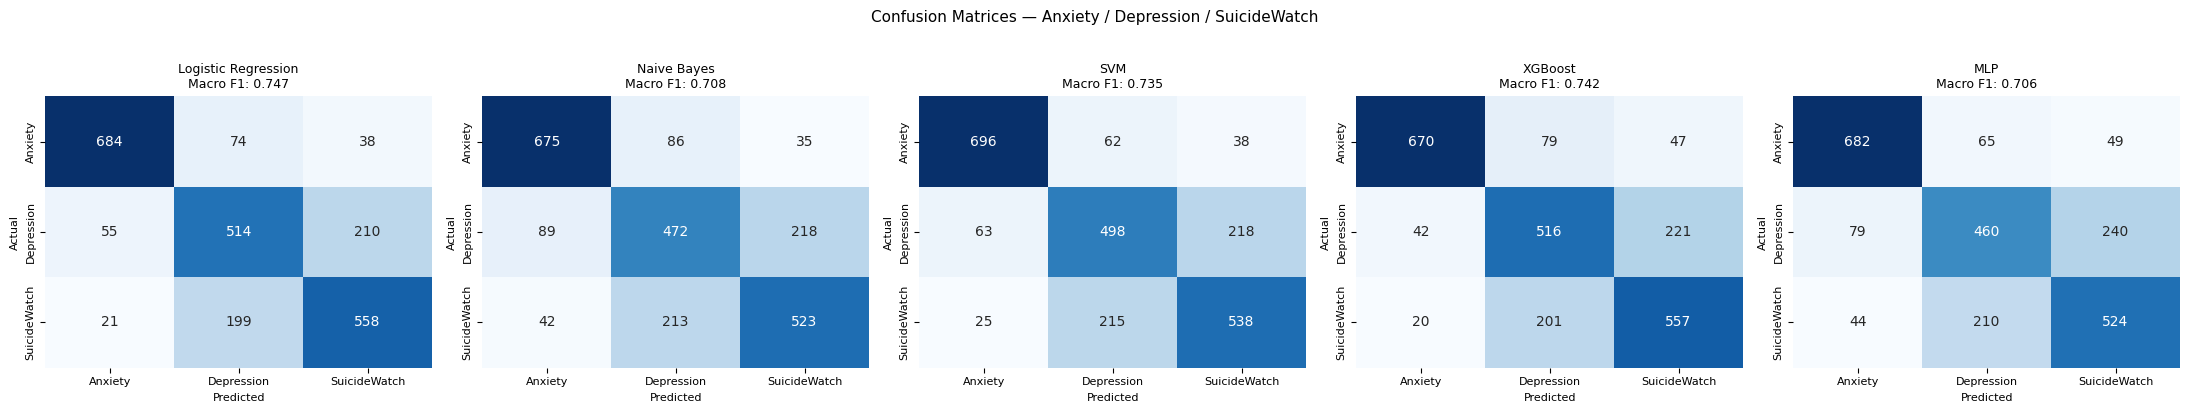

In [26]:
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, (name, model) in zip(axes, models.items()):
    use_enc = (name == 'XGBoost')
    preds_raw = model.predict(X_test)
    preds = le.inverse_transform(preds_raw) if use_enc else preds_raw

    cm = confusion_matrix(y_test, preds, labels=CLASSES)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        ax=ax, cbar=False
    )
    f1 = f1_score(y_test, preds, average='macro')
    ax.set_title(f'{name}\nMacro F1: {f1:.3f}', fontsize=9)
    ax.set_xlabel('Predicted', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle('Confusion Matrices — Anxiety / Depression / SuicideWatch', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

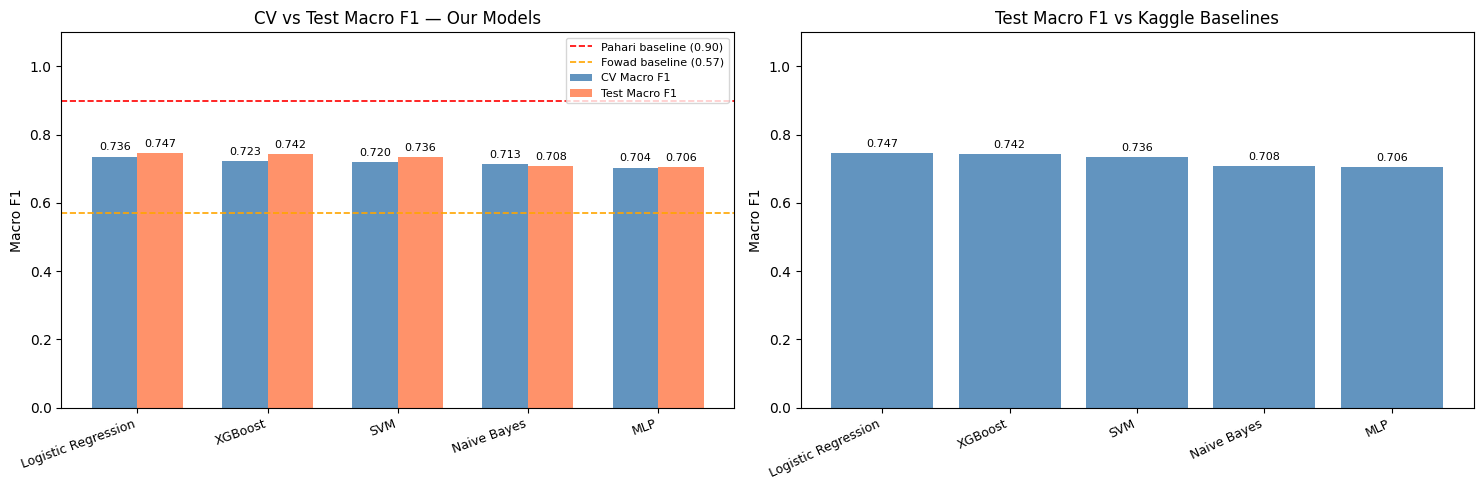

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
x = np.arange(len(results_df))
w = 0.35
b1 = ax.bar(x - w/2, results_df['CV Macro F1'],   w, label='CV Macro F1',   color='steelblue', alpha=0.85)
b2 = ax.bar(x + w/2, results_df['Test Macro F1'], w, label='Test Macro F1', color='coral',     alpha=0.85)
ax.axhline(y=0.90, color='red',    linestyle='--', linewidth=1.2, label='Pahari baseline (0.90)')
ax.axhline(y=0.57, color='orange', linestyle='--', linewidth=1.2, label='Fowad baseline (0.57)')
ax.set_title('CV vs Test Macro F1 — Our Models')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Macro F1')
ax.legend(fontsize=8)
ax.bar_label(b1, fmt='%.3f', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%.3f', padding=3, fontsize=8)

ax2 = axes[1]
all_names  = list(results_df['Model']) 
all_f1     = list(results_df['Test Macro F1']) 
bar_colors = ['steelblue'] * len(results_df) 
bars = ax2.bar(all_names, all_f1, color=bar_colors, alpha=0.85)
ax2.set_title('Test Macro F1 vs Kaggle Baselines')
ax2.set_xticklabels(all_names, rotation=25, ha='right', fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('Macro F1')
ax2.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

plt.tight_layout()
plt.savefig('f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
for name, model in models.items():
    use_enc = (name == 'XGBoost')
    preds_raw = model.predict(X_test)
    preds = le.inverse_transform(preds_raw) if use_enc else preds_raw
    print(f'\n{"-"*50}')
    print(f'  {name}')
    print(f'{"-"*50}')
    print(classification_report(y_test, preds, target_names=CLASSES))


--------------------------------------------------
  Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

     Anxiety       0.90      0.86      0.88       796
  Depression       0.65      0.66      0.66       779
SuicideWatch       0.69      0.72      0.70       778

    accuracy                           0.75      2353
   macro avg       0.75      0.75      0.75      2353
weighted avg       0.75      0.75      0.75      2353


--------------------------------------------------
  Naive Bayes
--------------------------------------------------
              precision    recall  f1-score   support

     Anxiety       0.84      0.85      0.84       796
  Depression       0.61      0.61      0.61       779
SuicideWatch       0.67      0.67      0.67       778

    accuracy                           0.71      2353
   macro avg       0.71      0.71      0.71      2353
weighted avg       0.71      0.71      0.71      23

In [24]:
results_df.to_csv('classical_results.csv', index=False)
print('\n===== Final=====')
print(results_df.to_string(index=False))


===== Final=====
              Model  CV Macro F1  CV Std  Test Macro F1  Test Acc  AUC-ROC
Logistic Regression       0.7359  0.0067         0.7467    0.7463   0.8969
            XGBoost       0.7228  0.0086         0.7424    0.7408   0.8948
                SVM       0.7195  0.0063         0.7355    0.7361   0.8846
        Naive Bayes       0.7130  0.0042         0.7083    0.7097   0.8763
                MLP       0.7036  0.0109         0.7061    0.7080   0.8696
